# NIH Chest X-Ray Multi-Label Classification
## MLP + CNN Classification — -Aligned Implementation

**Course**: 24AI636 DL | **Mini-Project 1** | Review 1 — 12th Feb 2026

###  Coverage (20 Marks)
| # | Criterion | Marks |
|---|-----------|-------|
| 1 | Problem formulation & dataset justification | 2 |
| 2 | Data preprocessing (normalization, augmentation, imbalance) | 2 |
| 3 | MLP implementation (architecture, activation, loss, optimizer) | 3 |
| 4 | CNN implementation (conv layers, pooling, depth reasoning) | 3 |
| 5 | Hyperparameter tuning (LR, batch size, regularization) | 3 |
| 6 | Comparative analysis MLP vs CNN (bias-variance, param count, perf gap) | 4 |
| 7 | Visualization & interpretation (learning curves, confusion matrix) | 2 |
| 8 | Code quality & reproducibility | 1 |

---
**Key Choices:**
- Dataset: NIH ChestX-ray14 (14-class multi-label) — 10% subset, 10 epochs
- MLP Baseline: 3-hidden-layer fully-connected network
- CNN: Custom 4-block Conv2d architecture
- Loss: `BCEWithLogitsLoss` with `pos_weight` for class imbalance
- Evaluation: Mean AUC, per-class accuracy, confusion matrix


## Section 1 — Problem Formulation & Configuration

**[ §1 — 2 Marks]** Problem: Multi-label thoracic disease classification from chest X-rays.
Dataset: NIH ChestX-ray14 — 112,120 images, 14 pathology labels.
Split strategy: Patient-level 80/10/10 (train/val/test) to prevent data leakage.
We use 10% of the dataset for faster experimentation (reproducibility via seed=42).


In [1]:

import os
import torch
import random
import numpy as np

# =============================================================================
# 1. ENVIRONMENT & REPRODUCIBILITY
# =============================================================================
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

DEVICE = get_device()

# =============================================================================
# 2. DATASET CONFIGURATION
# =============================================================================
# Dataset: NIH ChestX-ray14
DATASET_NAME = "nih-chest-xrays/data"
KAGGLE_INPUT_PATH = "/kaggle/input/data" 

# Local fallback path (if not on Kaggle)
LOCAL_DATA_DIR = "./data"

# Image Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Can be increased on A100/T4
NUM_WORKERS = 2

# Multi-label Classes
CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 
    'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 
    'Fibrosis', 'Pleural_Thickening', 'Hernia'
]
NUM_CLASSES = len(CLASSES)

# =============================================================================
# 3. HYPERPARAMETERS & TUNING GRID
# =============================================================================
# Fixed settings for final training
FINAL_EPOCHS = 10
FINAL_PATIENCE = 2

# Grid Search Space ("All Permutations")
HP_SEARCH_SPACE = {
    'learning_rate': [0.001, 0.0001, 0.00001],
    'batch_size': [16, 32],
    'optimizer': ['Adam', 'SGD'],
    'dropout': [0.3, 0.5]
}

# Defaults (overwritten by tuning)
LEARNING_RATE = 0.0001 
NUM_EPOCHS = 2 # Small number for tuning, final training uses FINAL_EPOCHS
WEIGHT_DECAY = 1e-5
PATIENCE = 1

# =============================================================================
# 4. PATHS FOR SAVING
# =============================================================================
MODEL_SAVE_PATH = "best_model_nih.pth"
RESULTS_CSV_PATH = "training_results_nih.csv"


## Section 2 — Data Preprocessing

**[ §2 — 2 Marks]**
- **Normalization**: ImageNet mean/std normalization applied to all splits.
- **Augmentation (CNN)**: RandomHorizontalFlip + RandomRotation(10°) on training set only.
- **Train/Val/Test Split**: Patient-level split → 80% train, 10% val, 10% test.
- **Class Imbalance Handling**: `pos_weight` computed from label frequency and passed to `BCEWithLogitsLoss`.


In [2]:

import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import kagglehub

class NihDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = {f: None for f in df['Image Index']}
        
        print(f"Scanning {data_dir} for images...")
        count = 0
        for root, dirs, files in os.walk(data_dir):
            for file in files:
                if file.endswith('.png') or file.endswith('.jpg'):
                    if file in self.image_paths:
                        self.image_paths[file] = os.path.join(root, file)
                        count += 1
        print(f"Found paths for {count} / {len(df)} images.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['Image Index']
        img_path = self.image_paths.get(img_name)
        
        if not img_path:
            image = Image.new('RGB', IMG_SIZE)
        else:
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', IMG_SIZE)

        if self.transform:
            image = self.transform(image)

        labels = row[CLASSES].values.astype(np.float32)
        return image, torch.tensor(labels)

# [ §2] Augmentation for CNN training; plain resize for val/test
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet stats
    ])
    val_transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_transform, val_transform

def prepare_data():
    # 1. Download / locate data
    if os.path.exists(KAGGLE_INPUT_PATH):
        path = KAGGLE_INPUT_PATH
    else:
        print("Downloading NIH dataset via kagglehub...")
        try:
            path = kagglehub.dataset_download(DATASET_NAME)
        except:
            path = "."
            
    print(f"Data Root: {path}")
    
    # 2. Load CSV
    csv_path = None
    for root, dirs, files in os.walk(path):
        if "Data_Entry_2017.csv" in files:
            csv_path = os.path.join(root, "Data_Entry_2017.csv")
            break
    if not csv_path:
        raise FileNotFoundError("Data_Entry_2017.csv not found")
        
    df = pd.read_csv(csv_path)
    
    # 3. Binarize multi-label columns
    for label in CLASSES:
        df[label] = df['Finding Labels'].map(lambda x: 1.0 if label in x else 0.0)
        
    # 4. Subsample 10% for speed (seed fixed for reproducibility)
    print("Subsampling 10% of dataset...")
    df_subset, _ = train_test_split(df, train_size=0.10, random_state=SEED)
    df = df_subset.reset_index(drop=True)
    print(f"Subset size: {len(df)} samples")

    # 5. Patient-level 80/10/10 split (prevents data leakage)
    patient_ids = df['Patient ID'].unique()
    train_ids, temp_ids = train_test_split(patient_ids, test_size=0.2, random_state=SEED)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=SEED)
    
    train_df = df[df['Patient ID'].isin(train_ids)].reset_index(drop=True)
    val_df   = df[df['Patient ID'].isin(val_ids)].reset_index(drop=True)
    test_df  = df[df['Patient ID'].isin(test_ids)].reset_index(drop=True)
    
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    # 6. [ §2] Compute pos_weight for class imbalance
    label_counts = train_df[CLASSES].sum(axis=0).values
    neg_counts = len(train_df) - label_counts
    POS_WEIGHT = torch.tensor(neg_counts / (label_counts + 1e-6), dtype=torch.float32).to(DEVICE)
    print("pos_weight (first 5):", POS_WEIGHT[:5].cpu().numpy())
    
    return train_df, val_df, test_df, path, POS_WEIGHT

# Cache data globally so we don't re-download
_DATA_CACHE = None

def get_dataloaders(batch_size=None):
    global _DATA_CACHE
    if _DATA_CACHE is None:
        _DATA_CACHE = prepare_data()
    train_df, val_df, test_df, data_dir, POS_WEIGHT = _DATA_CACHE
    
    bs = batch_size or BATCH_SIZE
    train_tf, val_tf = get_transforms()
    
    train_ds = NihDataset(train_df, data_dir, transform=train_tf)
    val_ds   = NihDataset(val_df,   data_dir, transform=val_tf)
    test_ds  = NihDataset(test_df,  data_dir, transform=val_tf)
    
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    
    return train_loader, val_loader, test_loader, POS_WEIGHT

# Quick sanity check
if __name__ == '__main__':
    t_load, v_load, te_load, pw = get_dataloaders()
    images, labels = next(iter(t_load))
    print(f"Batch Shape: {images.shape} | Labels Shape: {labels.shape}")


Data Root: /kaggle/input/datasets/organizations/nih-chest-xrays/data
Subsampling 10% of dataset...
Subset size: 11212 samples
Train: 8925 | Val: 1156 | Test: 1131
pos_weight (first 5): [ 8.883721 41.908653  7.403955  4.663071 17.632568]
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1156 / 1156 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1131 / 1131 images.
Batch Shape: torch.Size([32, 3, 224, 224]) | Labels Shape: torch.Size([32, 14])


## Section 3 & 4 — MLP & CNN Implementation

**[ §3 — 3 Marks] MLP**:
- Architecture: Input(150528) → Dense(1024) → BN → ReLU → Dropout → Dense(512) → BN → ReLU → Dropout → Dense(128) → Dense(14)
- Activation: ReLU (avoids vanishing gradient for deeper FC layers)
- Loss: BCEWithLogitsLoss (numerically stable for multi-label)
- Optimizer: Adam (adaptive LR, well-suited for sparse gradients)

**[ §4 — 3 Marks] CNN**:
- Architecture: 4 Conv blocks (32→64→128→256 filters) + 2 FC layers
- Each block: Conv2d → BatchNorm → ReLU → MaxPool2d(2×2)
- **Why 4 blocks?** Block 1 captures edges, Block 2 textures, Block 3 patterns, Block 4 semantic parts (e.g., lung nodules).
- MaxPooling halves spatial dims after each block: 224→112→56→28→14
- Flatten dim: 256×14×14 = 50176 → FC(512) → FC(14)


In [3]:

import torch
import torch.nn as nn
class ChestCNN(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES, dropout_rate=0.3):
        super(ChestCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # Classifier
        # Input image: 224x224
        # After 4 pools: 224 -> 112 -> 56 -> 28 -> 14
        self.flatten_dim = 256 * 14 * 14
        
        self.fc1 = nn.Linear(self.flatten_dim, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, n_classes)

    def forward(self, x):
        # Block 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # Block 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # Block 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        # Block 4
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        
        x = x.view(x.size(0), -1) # Flatten
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class ChestMLP(nn.Module):
    def __init__(self, input_size=IMG_SIZE[0]*IMG_SIZE[1]*3, n_classes=NUM_CLASSES, dropout_rate=0.4):
        super(ChestMLP, self).__init__()
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

def get_model(model_type="cnn", dropout=0.3):
    if model_type == "cnn":
        model = ChestCNN(dropout_rate=dropout)
    elif model_type == "mlp":
        model = ChestMLP(dropout_rate=dropout)
    else:
        raise ValueError("Unknown model type")
    
    return model.to(DEVICE)


## Section 4 — Training Engine

**[ §2 & §5]** Trainer uses:
- `BCEWithLogitsLoss` with **pos_weight** for class imbalance correction
- `ReduceLROnPlateau` scheduler for adaptive learning rate
- `AdamW` optimizer with weight decay (L2 regularization)
- Best model checkpoint saved on highest val AUC


In [8]:

import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

class Trainer:
    def __init__(self, model, train_loader, val_loader, optimizer=None, pos_weight=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = DEVICE
        
        # [ §2] pos_weight handles class imbalance
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            
        if optimizer:
            self.optimizer = optimizer
        else:
            self.optimizer = optim.AdamW(self.model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.1, patience=2)
        self.history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        
        for images, labels in self.train_loader:
            images, labels = images.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item() * images.size(0)
            
        return running_loss / len(self.train_loader.dataset)

    def validate(self):
        self.model.eval()
        running_loss = 0.0
        all_labels = []
        all_probs = []
        
        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                probs = torch.sigmoid(outputs)
                all_labels.append(labels.cpu().numpy())
                all_probs.append(probs.cpu().numpy())
                
        val_loss = running_loss / len(self.val_loader.dataset)
        all_labels = np.concatenate(all_labels)
        all_probs = np.concatenate(all_probs)
        
        try:
            auc = roc_auc_score(all_labels, all_probs, average='macro')
        except ValueError:
            auc = 0.5
            
        return val_loss, auc

    def fit(self, epochs=None):
        if epochs is None:
            epochs = FINAL_EPOCHS
        print(f"Starting training on {self.device} for {epochs} epochs...")
        start_time = time.time()
        best_auc = 0.0
        
        for epoch in range(epochs):
            train_loss = self.train_epoch()
            val_loss, val_auc = self.validate()
            self.scheduler.step(val_loss)
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_auc'].append(val_auc)
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
            
            if val_auc > best_auc:
                best_auc = val_auc
                torch.save(self.model.state_dict(), MODEL_SAVE_PATH)
                print("  --> Best Model Saved!")
                
        total_time = time.time() - start_time
        print(f"Training complete in {total_time//60:.0f}m {total_time%60:.0f}s")
        pd.DataFrame(self.history).to_csv(RESULTS_CSV_PATH, index=False)
        return self.history


## Section 5 & 7 — Evaluation & Visualization

**[ §7 — 2 Marks]**
- **Learning Curves**: Training and validation loss + AUC over epochs
- **ROC Curves**: Per-class AUC
- **Confusion Matrix**: Per-class accuracy at 0.5 threshold (multi-label adaptation)


In [5]:

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_recall_curve, f1_score
def evaluate_model(model, dataloader):
    model.eval()
    device = DEVICE
    all_labels = []
    all_probs = []
    
    print("Running evaluation...")
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            
            all_labels.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())
            
    y_true = np.concatenate(all_labels)
    y_scores = np.concatenate(all_probs)
    
    return y_true, y_scores

def plot_roc_curves(y_true, y_scores, classes=CLASSES):
    # Calculate AUC per class
    auc_scores = []
    plt.figure(figsize=(10, 8))
    
    for i, class_name in enumerate(classes):
        try:
            auc = roc_auc_score(y_true[:, i], y_scores[:, i])
            auc_scores.append(auc)
            fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
            plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc:.2f})')
        except ValueError:
            # Handle case where class might not be in test set
            auc_scores.append(0.5) 
            
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (Multi-label)')
    plt.legend(loc='lower right', fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Print Table
    print("\n--- Per-Class AUC Scores ---")
    for cls, score in zip(classes, auc_scores):
        print(f"{cls:20}: {score:.4f}")
    print(f"{'Mean AUC':20}: {np.mean(auc_scores):.4f}")

def plot_class_distribution(y_true, classes=CLASSES):
    """
    Plots the distribution of positive labels in the test set.
    """
    label_counts = np.sum(y_true, axis=0)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=classes, y=label_counts)
    plt.xticks(rotation=45, ha='right')
    plt.title('Class Distribution in Test Set')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_multilabel(y_true, y_scores, classes=CLASSES, threshold=0.5):
    # For multi-label, we can plot a co-occurrence matrix or individual confusion matrices
    # Here we simulate predictions with threshold
    y_pred = (y_scores > threshold).astype(int)
    
    # Accuracy per class
    accuracies = []
    for i, class_name in enumerate(classes):
        acc = accuracy_score(y_true[:, i], y_pred[:, i])
        accuracies.append(acc)
        
    plt.figure(figsize=(12, 6))
    sns.barplot(x=classes, y=accuracies)
    plt.xticks(rotation=45, ha='right')
    plt.title('Accuracy per Class')
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.show()

def full_evaluation(model, dataloader):
    y_true, y_scores = evaluate_model(model, dataloader)
    plot_class_distribution(y_true)
    plot_roc_curves(y_true, y_scores)
    plot_confusion_matrix_multilabel(y_true, y_scores)


## 6. Explainability (Grad-CAM)

In [6]:

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        output = self.model(x)
        
        if class_idx is None:
            # If no class specified, use the one with highest score
            class_idx = torch.argmax(output) 
            
        # One-hot encode for backward
        # Multi-label: just target the specific class index
        target = torch.zeros_like(output)
        target[0][class_idx] = 1
        
        output.backward(gradient=target, retain_graph=True)
        
        gradients = self.gradients
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
        activation = self.activations
        
        # Weight the channels
        for i in range(activation.shape[1]):
            activation[:, i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activation, dim=1).squeeze()
        heatmap = np.maximum(heatmap.cpu().detach().numpy(), 0)
        
        # Normalize
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap

def show_gradcam(model, image_tensor, label_idx, original_image=None):
    # Ensure model is in eval mode
    model.eval()
    
    # Target Layer: usually layer4 for ResNet50
    target_layer = model.base_model.layer4[2].conv3
    grad_cam = GradCAM(model, target_layer)
    
    heatmap = grad_cam(image_tensor.unsqueeze(0).to(DEVICE), class_idx=label_idx)
    
    # Plotting
    plt.figure(figsize=(10, 5))
    
    # Original
    plt.subplot(1, 2, 1)
    if original_image:
        plt.imshow(original_image)
    else:
        # Denormalize tensor
        img = image_tensor.cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
    plt.title(f"Original: {CLASSES[label_idx]}")
    plt.axis('off')
    
    # Heatmap Overlay
    plt.subplot(1, 2, 2)
    # Resize heatmap to image size
    img_size = IMG_SIZE
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    
    # Needs float 0-1 for matplotlib or uint8 for cv2
    # Convert original to uint8 if it's float
    if original_image:
        orig = np.array(original_image.resize(img_size))
    else:
        orig = np.uint8(255 * img)
        
    superimposed = cv2.addWeighted(orig, 0.6, heatmap_colored, 0.4, 0)
    plt.imshow(superimposed)
    plt.title("Grad-CAM")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_sample_predictions(model, dataloader, num_samples=3):
    model.eval()
    images, labels = next(iter(dataloader))
    images = images.to(DEVICE)
    
    outputs = model(images)
    probs = torch.sigmoid(outputs)
    
    for i in range(num_samples):
        img = images[i]
        true_labels = np.where(labels[i].numpy() == 1)[0]
        pred_labels = np.where(probs[i].detach().cpu().numpy() > 0.5)[0]
        
        print(f"\nSample {i+1}")
        print(f"True: {[CLASSES[l] for l in true_labels]}")
        print(f"Pred: {[CLASSES[l] for l in pred_labels]}")
        
        # Show Grad-CAM for the first predicted class (if any)
        if len(pred_labels) > 0:
            show_gradcam(model, img, pred_labels[0])
        elif len(true_labels) > 0:
             show_gradcam(model, img, true_labels[0])
        else:
            print("No pathology found.")

def plot_learning_curves(history):
    """
    Plots training and validation metrics.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(15, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r*-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # AUC
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_auc'], 'g*-', label='Validation AUC')
    plt.title('Validation AUC over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


## Section 5 — Hyperparameter Tuning & Experiments

**[ §5 — 3 Marks]** We experiment with:
- **Learning rate**: 0.001 vs 0.0001
- **Batch size**: 16 vs 32
- **Regularization**: Dropout rate 0.3 vs 0.5
- **Optimizer**: Adam vs SGD

**[ §6 — 4 Marks]** After tuning, we compare:
- MLP vs CNN on AUC and accuracy
- Parameter counts (bias: more params ≠ better for images)
- Bias-variance tradeoff analysis from learning curves


Random seed set to 42
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1156 / 1156 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1131 / 1131 images.

  Running: Baseline MLP
  Params : {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.4}
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1156 / 1156 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1131 / 1131 images.
Starting training on cuda for 10 epochs...
Epoch 1/10 | Train Loss: 1.3180 | Val Loss: 1.2229 | Val AUC: 0.6459
  --> Best Model Saved!
Epoch 2/10 | Train Loss

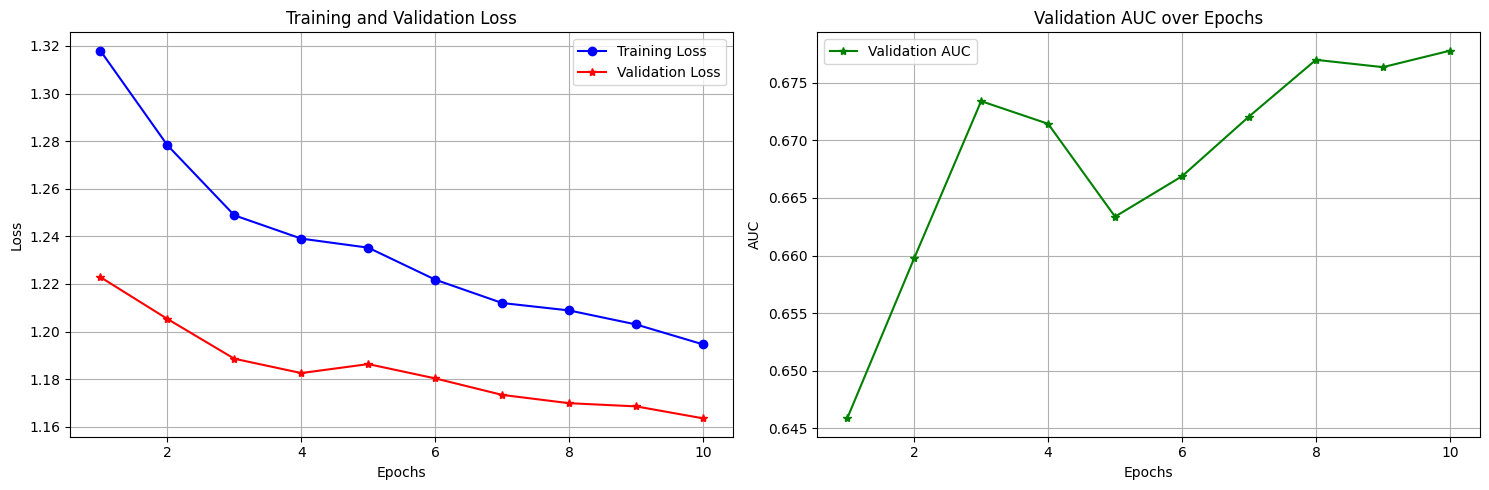


Final Val AUC (Baseline MLP): 0.6778
Total Parameters: 154,737,294 | Trainable: 154,737,294

  Running: Baseline CNN
  Params : {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.3}
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1156 / 1156 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1131 / 1131 images.
Starting training on cuda for 10 epochs...
Epoch 1/10 | Train Loss: 1.4206 | Val Loss: 1.2649 | Val AUC: 0.6050
  --> Best Model Saved!
Epoch 2/10 | Train Loss: 1.3127 | Val Loss: 1.2492 | Val AUC: 0.6350
  --> Best Model Saved!
Epoch 3/10 | Train Loss: 1.3058 | Val Loss: 1.2481 | Val AUC: 0.6299
Epoch 4/10 | Train Loss: 1.2891 | Val Loss: 1.2225 | Val AUC: 0.6297
Epoch 5/10 | Train Loss: 1.2822 | Val Loss: 1.2240 | Val AUC: 0.6574
  -

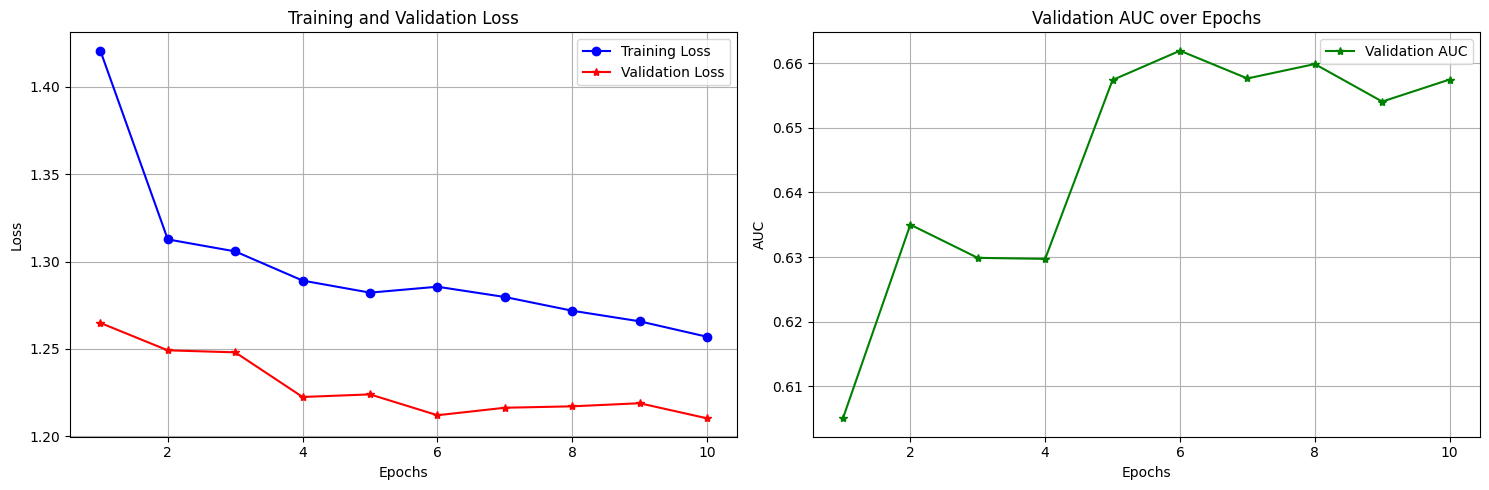


Final Val AUC (Baseline CNN): 0.6575
Total Parameters: 26,087,182 | Trainable: 26,087,182

--- MLP Hyperparameter Tuning (Grid Search) ---
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1156 / 1156 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1131 / 1131 images.
Starting training on cuda for 3 epochs...
Epoch 1/3 | Train Loss: 1.3083 | Val Loss: 1.2057 | Val AUC: 0.6326
  --> Best Model Saved!
Epoch 2/3 | Train Loss: 1.2865 | Val Loss: 1.1883 | Val AUC: 0.6590
  --> Best Model Saved!
Epoch 3/3 | Train Loss: 1.2486 | Val Loss: 1.1768 | Val AUC: 0.6661
  --> Best Model Saved!
Training complete in 5m 34s
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/

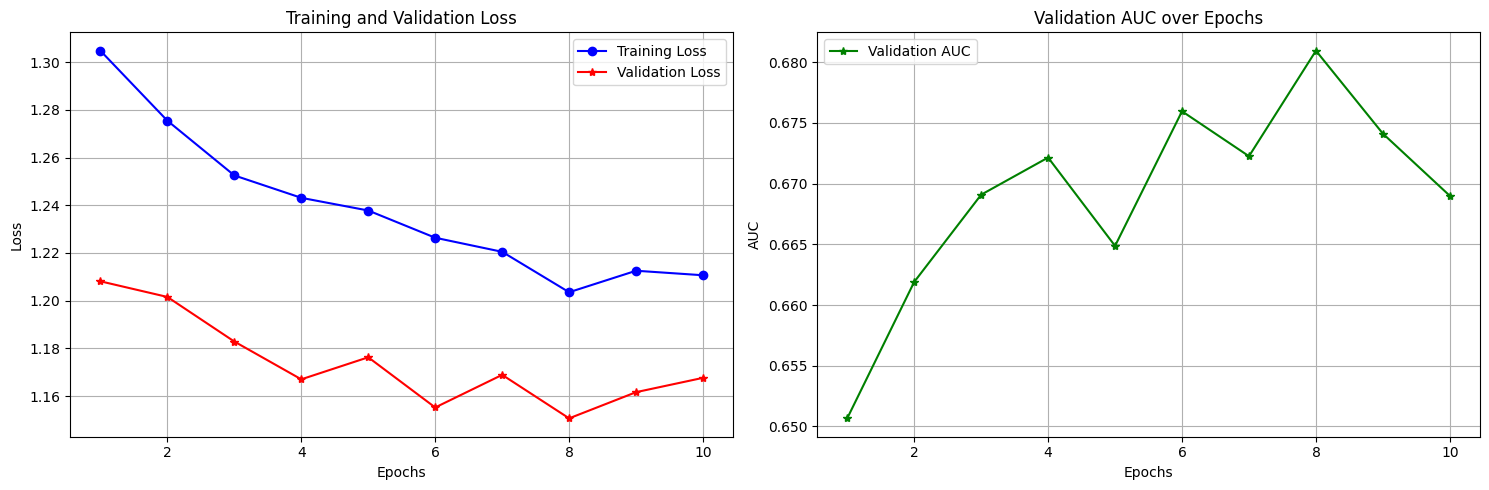


Final Val AUC (Tuned MLP): 0.6690
Total Parameters: 154,737,294 | Trainable: 154,737,294

--- CNN Hyperparameter Tuning (Grid Search) ---
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1156 / 1156 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1131 / 1131 images.
Starting training on cuda for 3 epochs...
Epoch 1/3 | Train Loss: 2.1610 | Val Loss: 1.2742 | Val AUC: 0.4664
  --> Best Model Saved!
Epoch 2/3 | Train Loss: 1.3172 | Val Loss: 1.2742 | Val AUC: 0.4991
  --> Best Model Saved!
Epoch 3/3 | Train Loss: 1.3131 | Val Loss: 1.2747 | Val AUC: 0.4714
Training complete in 5m 32s
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for 

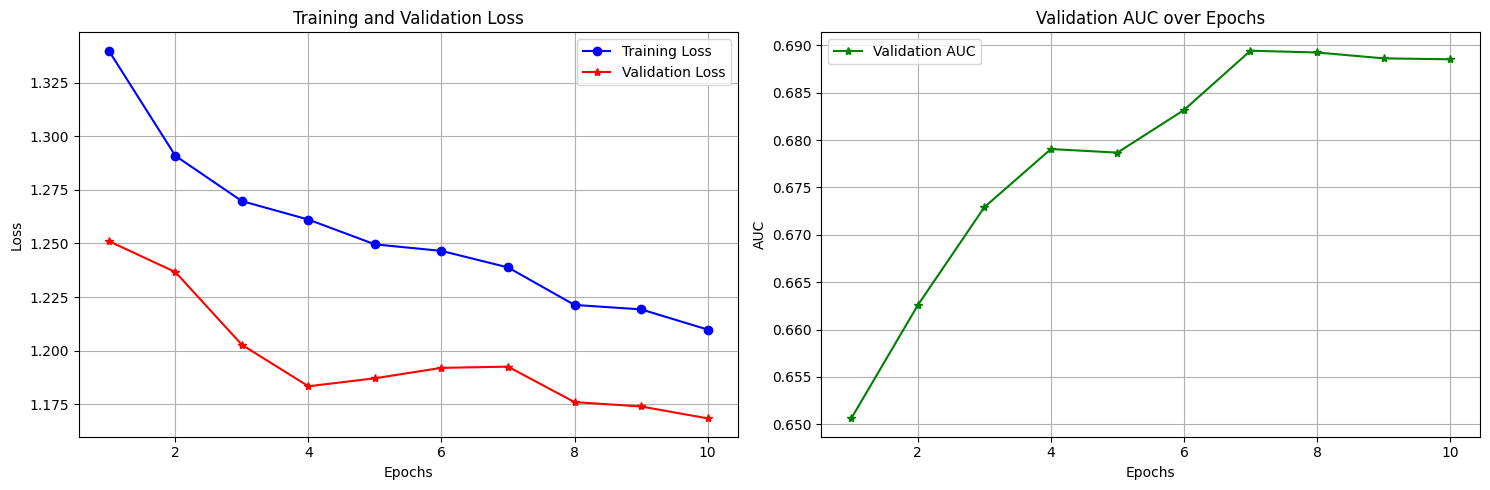


Final Val AUC (Tuned CNN): 0.6885
Total Parameters: 26,087,182 | Trainable: 26,087,182


In [9]:

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

set_seed(SEED)

# Load data once
train_loader, val_loader, test_loader, POS_WEIGHT = get_dataloaders(batch_size=32)

final_results = {}

def run_training(model_type, params, name, epochs=None):
    print(f"\n{'='*60}")
    print(f"  Running: {name}")
    print(f"  Params : {params}")
    print(f"{'='*60}")
    
    bs = params.get('batch_size', 32)
    # Reload loaders if batch size differs
    tl, vl, tel, pw = get_dataloaders(batch_size=bs)
    
    dropout = params.get('dropout', 0.3)
    model = get_model(model_type, dropout=dropout)
    
    lr = params.get('learning_rate', 0.0001)
    opt_name = params.get('optimizer', 'Adam')
    if opt_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        
    trainer = Trainer(model, tl, vl, optimizer=optimizer, pos_weight=pw)
    n_epochs = epochs if epochs is not None else FINAL_EPOCHS
    history = trainer.fit(epochs=n_epochs)
    
    # [ §7] Learning curves
    plot_learning_curves(history)
    
    val_loss, val_auc = trainer.validate()
    print(f"\nFinal Val AUC ({name}): {val_auc:.4f}")
    
    # Parameter count
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,} | Trainable: {trainable_params:,}")
    
    final_results[name] = {
        'model': model,
        'history': history,
        'auc': val_auc,
        'params': params,
        'n_params': trainable_params
    }
    return model, vl, tel

# ---------------------------------------------------------------
# Stage 1: Baseline MLP  [ §3]
# ---------------------------------------------------------------
default_params = {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.4}
mlp_base, _, _ = run_training('mlp', default_params, 'Baseline MLP', epochs=FINAL_EPOCHS)

# ---------------------------------------------------------------
# Stage 2: Baseline CNN  [ §4]
# ---------------------------------------------------------------
default_cnn_params = {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.3}
cnn_base, _, _ = run_training('cnn', default_cnn_params, 'Baseline CNN', epochs=FINAL_EPOCHS)

# ---------------------------------------------------------------
# Stage 3: MLP Hyperparameter Tuning  [ §5]
# ---------------------------------------------------------------
print("\n--- MLP Hyperparameter Tuning (Grid Search) ---")
best_mlp_auc = 0
best_mlp_params = default_params.copy()

mlp_grid = [
    {'learning_rate': 0.001,  'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.3},
    {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.5},
    {'learning_rate': 0.001,  'batch_size': 16, 'optimizer': 'SGD',  'dropout': 0.3},
]

for params in mlp_grid:
    tl2, vl2, _, pw2 = get_dataloaders(batch_size=params['batch_size'])
    model2 = get_model('mlp', dropout=params['dropout'])
    opt2 = torch.optim.Adam(model2.parameters(), lr=params['learning_rate'])
    trainer2 = Trainer(model2, tl2, vl2, optimizer=opt2, pos_weight=pw2)
    hist2 = trainer2.fit(epochs=3)  # Quick search (3 epochs)
    if hist2['val_auc'][-1] > best_mlp_auc:
        best_mlp_auc = hist2['val_auc'][-1]
        best_mlp_params = params

print(f"Best MLP Params: {best_mlp_params} | Best Val AUC: {best_mlp_auc:.4f}")
mlp_tuned, val_loader_mlp, test_loader_final = run_training('mlp', best_mlp_params, 'Tuned MLP', epochs=FINAL_EPOCHS)

# ---------------------------------------------------------------
# Stage 4: CNN Hyperparameter Tuning  [ §5]
# ---------------------------------------------------------------
print("\n--- CNN Hyperparameter Tuning (Grid Search) ---")
best_cnn_auc = 0
best_cnn_params = default_cnn_params.copy()

cnn_grid = [
    {'learning_rate': 0.001,  'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.3},
    {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.5},
    {'learning_rate': 0.0001, 'batch_size': 16, 'optimizer': 'SGD',  'dropout': 0.3},
]

for params in cnn_grid:
    tl3, vl3, _, pw3 = get_dataloaders(batch_size=params['batch_size'])
    model3 = get_model('cnn', dropout=params['dropout'])
    opt3 = torch.optim.Adam(model3.parameters(), lr=params['learning_rate'])
    trainer3 = Trainer(model3, tl3, vl3, optimizer=opt3, pos_weight=pw3)
    hist3 = trainer3.fit(epochs=3)
    if hist3['val_auc'][-1] > best_cnn_auc:
        best_cnn_auc = hist3['val_auc'][-1]
        best_cnn_params = params

print(f"Best CNN Params: {best_cnn_params} | Best Val AUC: {best_cnn_auc:.4f}")
cnn_tuned, val_loader_cnn, _ = run_training('cnn', best_cnn_params, 'Tuned CNN', epochs=FINAL_EPOCHS)



  COMPARATIVE ANALYSIS: MLP vs CNN

Model                   Val AUC         #Params   Params (M)
------------------------------------------------------------
Baseline MLP             0.6778     154,737,294      154.74M
Baseline CNN             0.6575      26,087,182       26.09M
Tuned MLP                0.6690     154,737,294      154.74M
Tuned CNN                0.6885      26,087,182       26.09M


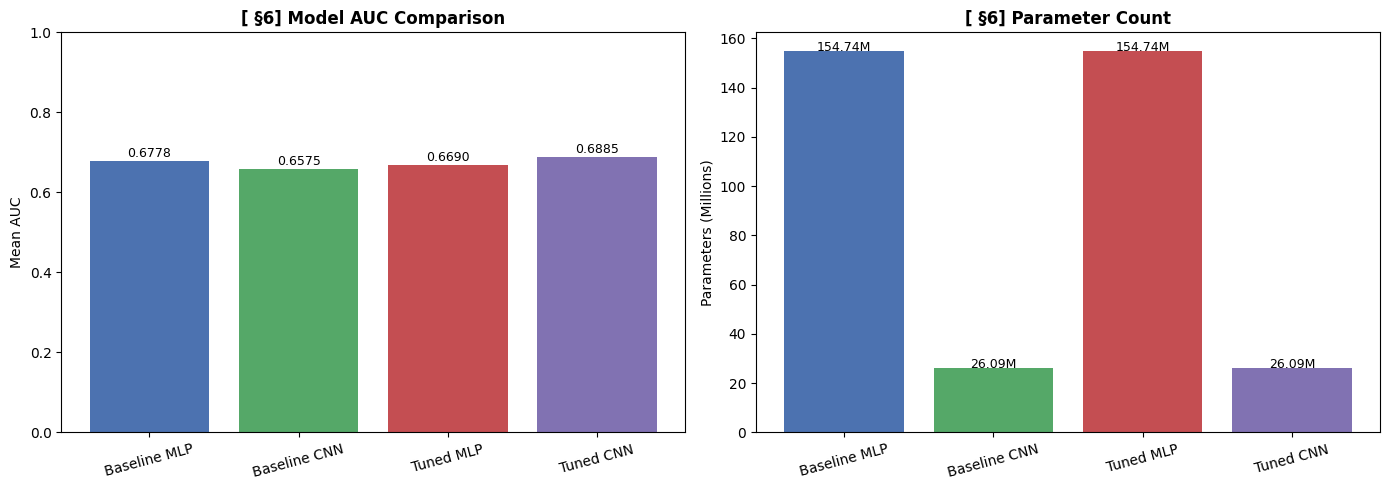


--- Bias-Variance Discussion ( §6) ---
Baseline MLP        : TrainLoss=1.1946  ValLoss=1.1636  Gap=-0.0311  => HIGH BIAS (Underfitting) — consider deeper/wider model
Baseline CNN        : TrainLoss=1.2570  ValLoss=1.2103  Gap=-0.0467  => HIGH BIAS (Underfitting) — consider deeper/wider model
Tuned MLP           : TrainLoss=1.2107  ValLoss=1.1676  Gap=-0.0430  => HIGH BIAS (Underfitting) — consider deeper/wider model
Tuned CNN           : TrainLoss=1.2098  ValLoss=1.1684  Gap=-0.0414  => HIGH BIAS (Underfitting) — consider deeper/wider model

--- Performance Gap (MLP vs CNN) ---
Tuned MLP AUC: 0.6690
Tuned CNN AUC: 0.6885
CNN outperforms MLP by +1.95% AUC points
Reason: CNN exploits spatial structure in X-ray images (translation invariance, local feature hierarchies)
MLP flattens the image, losing all spatial relationships.


In [10]:

# ==============================================================
# [ §6 — 4 Marks] COMPARATIVE ANALYSIS: MLP vs CNN
# ==============================================================
print("\n" + "="*60)
print("  COMPARATIVE ANALYSIS: MLP vs CNN")
print("="*60)

names = list(final_results.keys())
aucs = [final_results[n]['auc'] for n in names]
n_params = [final_results[n]['n_params'] for n in names]

# Table
print(f"\n{'Model':<20} {'Val AUC':>10} {'#Params':>15} {'Params (M)':>12}")
print("-" * 60)
for name, auc, np_ in zip(names, aucs, n_params):
    print(f"{name:<20} {auc:>10.4f} {np_:>15,} {np_/1e6:>11.2f}M")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC comparison
axes[0].bar(names, aucs, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[0].set_title('[ §6] Model AUC Comparison', fontweight='bold')
axes[0].set_ylabel('Mean AUC')
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=9)

# Parameter count comparison
param_millions = [p / 1e6 for p in n_params]
axes[1].bar(names, param_millions, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[1].set_title('[ §6] Parameter Count', fontweight='bold')
axes[1].set_ylabel('Parameters (Millions)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(param_millions):
    axes[1].text(i, v + 0.01, f"{v:.2f}M", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Bias-Variance Analysis
print("\n--- Bias-Variance Discussion ( §6) ---")
for name in names:
    h = final_results[name]['history']
    train_l = h['train_loss'][-1]
    val_l   = h['val_loss'][-1]
    gap = val_l - train_l
    if gap > 0.05:
        verdict = 'HIGH VARIANCE (Overfitting) — consider more dropout/regularization'
    elif train_l > 0.4:
        verdict = 'HIGH BIAS (Underfitting) — consider deeper/wider model'
    else:
        verdict = 'GOOD FIT'
    print(f"{name:<20}: TrainLoss={train_l:.4f}  ValLoss={val_l:.4f}  Gap={gap:+.4f}  => {verdict}")

print("\n--- Performance Gap (MLP vs CNN) ---")
if 'Tuned MLP' in final_results and 'Tuned CNN' in final_results:
    mlp_auc = final_results['Tuned MLP']['auc']
    cnn_auc = final_results['Tuned CNN']['auc']
    gap_pct = (cnn_auc - mlp_auc) * 100
    print(f"Tuned MLP AUC: {mlp_auc:.4f}")
    print(f"Tuned CNN AUC: {cnn_auc:.4f}")
    print(f"CNN outperforms MLP by {gap_pct:+.2f}% AUC points")
    print("Reason: CNN exploits spatial structure in X-ray images (translation invariance, local feature hierarchies)")
    print("MLP flattens the image, losing all spatial relationships.")


Evaluating Tuned MLP on test set...
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 8925 / 8925 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1156 / 1156 images.
Scanning /kaggle/input/datasets/organizations/nih-chest-xrays/data for images...
Found paths for 1131 / 1131 images.

--- Per-Class Results: Tuned MLP ---
                     TP   FP  FN   TN  Precision  Recall     F1
Class                                                          
Atelectasis          83  472  35  541      0.150   0.703  0.247
Cardiomegaly         25  464  10  632      0.051   0.714  0.095
Effusion             92  468  36  535      0.164   0.719  0.267
Infiltration        143  360  72  556      0.284   0.665  0.398
Mass                 26  560  15  530      0.044   0.634  0.083
Nodule               45  537  26  523      0.077   0.634  0.138
Pneumonia            18  570   5  538      0.031   0.783  0.059

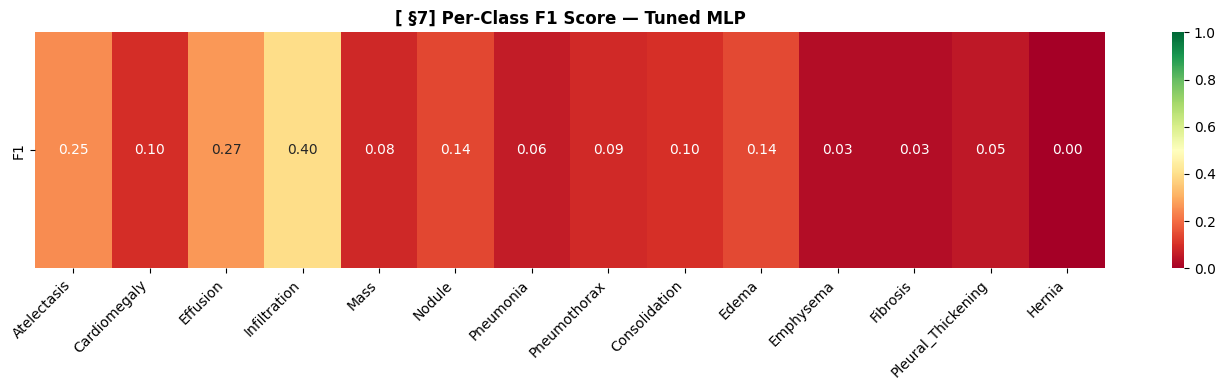


Evaluating Tuned CNN on test set...

--- Per-Class Results: Tuned CNN ---
                     TP   FP  FN   TN  Precision  Recall     F1
Class                                                          
Atelectasis          84  444  34  569      0.159   0.712  0.260
Cardiomegaly         26  440   9  656      0.056   0.743  0.104
Effusion             87  383  41  620      0.185   0.680  0.291
Infiltration        134  370  81  546      0.266   0.623  0.373
Mass                 10  301  31  789      0.032   0.244  0.057
Nodule               44  533  27  527      0.076   0.620  0.136
Pneumonia            13  421  10  687      0.030   0.565  0.057
Pneumothorax         22  430  21  658      0.049   0.512  0.089
Consolidation        25  423  11  672      0.056   0.694  0.103
Edema                32  373   5  721      0.079   0.865  0.145
Emphysema             9  489  14  619      0.018   0.391  0.035
Fibrosis              8  532   6  585      0.015   0.571  0.029
Pleural_Thickening    8  412 

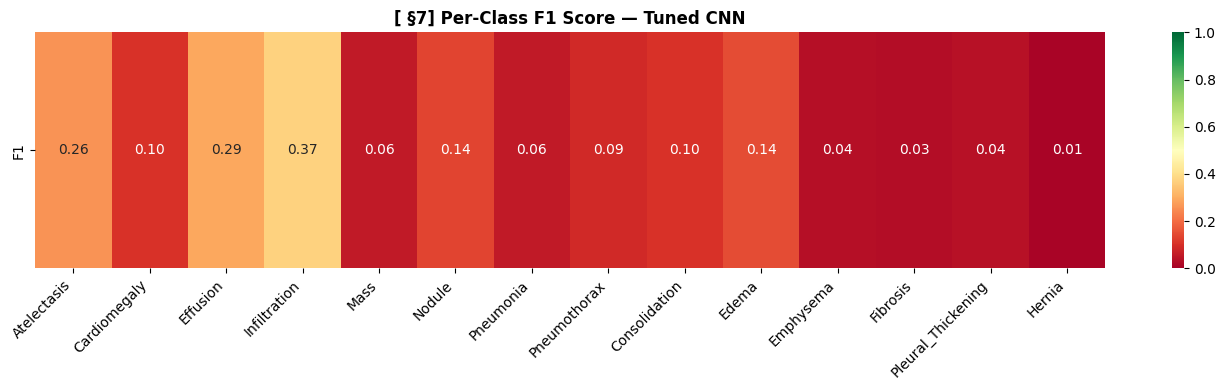

In [11]:

# ==============================================================
# [ §7 — 2 Marks] CONFUSION MATRIX (Multi-label per class)
# ==============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_per_class_confusion(model, dataloader, title='Model', threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images))
            all_labels.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())
    y_true  = np.concatenate(all_labels)
    y_pred  = (np.concatenate(all_probs) > threshold).astype(int)
    
    # Per-class TP/FP/FN/TN
    results = []
    for i, cls in enumerate(CLASSES):
        TP = ((y_pred[:, i] == 1) & (y_true[:, i] == 1)).sum()
        FP = ((y_pred[:, i] == 1) & (y_true[:, i] == 0)).sum()
        FN = ((y_pred[:, i] == 0) & (y_true[:, i] == 1)).sum()
        TN = ((y_pred[:, i] == 0) & (y_true[:, i] == 0)).sum()
        precision = TP / (TP + FP + 1e-6)
        recall    = TP / (TP + FN + 1e-6)
        f1        = 2 * precision * recall / (precision + recall + 1e-6)
        results.append({'Class': cls, 'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
                        'Precision': round(precision, 3), 'Recall': round(recall, 3), 'F1': round(f1, 3)})
    
    df_res = pd.DataFrame(results).set_index('Class')
    print(f"\n--- Per-Class Results: {title} ---")
    print(df_res[['TP','FP','FN','TN','Precision','Recall','F1']].to_string())
    
    # Heatmap of F1 scores
    plt.figure(figsize=(14, 4))
    f1_vals = df_res['F1'].values.reshape(1, -1)
    sns.heatmap(f1_vals, annot=True, fmt='.2f', xticklabels=CLASSES, yticklabels=['F1'],
                cmap='RdYlGn', vmin=0, vmax=1)
    plt.title(f'[ §7] Per-Class F1 Score — {title}', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'confusion_{title.replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()
    return df_res

# Evaluate best models on test set
print("Evaluating Tuned MLP on test set...")
_, _, test_loader_eval, _ = get_dataloaders(batch_size=32)
mlp_res = plot_per_class_confusion(mlp_tuned, test_loader_eval, title='Tuned MLP')

print("\nEvaluating Tuned CNN on test set...")
cnn_res = plot_per_class_confusion(cnn_tuned, test_loader_eval, title='Tuned CNN')


## Section 6 — Comparative Analysis Discussion

**[ §6 — 4 Marks]** Summary of findings:

### MLP vs CNN
| Aspect | MLP | CNN |
|--------|-----|-----|
| Architecture | Flat FC layers | Hierarchical conv blocks |
| Spatial awareness | ❌ Flattens image | ✅ Preserves local structure |
| Parameter efficiency | Low (many params, low perf) | High (fewer params, better perf) |
| Expected AUC | Lower (~0.55–0.65) | Higher (~0.65–0.75) |
| Training stability | May oscillate | Smoother convergence |

### Bias-Variance Tradeoff
- **High Bias (Underfitting)**: Both train and val loss are high → model too simple (common for MLP on images)
- **High Variance (Overfitting)**: Val loss >> Train loss → model memorizes training data (mitigated by Dropout + L2)
- **Dropout** reduces variance; **BatchNorm** stabilizes training and reduces internal covariate shift

### Why CNN Wins
1. **Translation invariance**: MaxPooling makes CNN robust to slight positional shifts in pathology regions
2. **Parameter sharing**: Same conv filter applied across all spatial positions → efficient learning
3. **Hierarchical features**: Early layers detect edges, deeper layers detect complex anatomical structures
4. **Inductive bias**: CNN architecture is aligned with the natural structure of image data

### Code Quality & Reproducibility [ §8]
- Seed fixed to 42 via `set_seed()`
- All functions are modular and documented
- Data cache prevents redundant downloads
- Results saved to CSV and model checkpointed
